# 00 -- EDA: что нужно предсказать

На входе текст запроса и его контекст. На выходе до 50 **идентификаторов** объявлений из заданного корпуса.
Цель -- macro Recall@50 по запросам, а не accuracy по строкам и не предсказание цены.
Разметка содержит только выбранные объявления: отсутствие пары не означает нерелевантность.
Нет timestamps, показов, user/session ID. Временной backtest, CTR и персонализация здесь не идентифицируемы.

Этот ноутбук читает исходные данные; не меняет их. Переменные имеют префикс `eda_`.
Графики каталога считаются по уникальным item_id: частые клики не должны умножать вес объявления.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

eda_root = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
get_ipython().run_line_magic('run', str(eda_root / 'notebooks/common.ipynb'))

eda_out = eda_root / 'outputs'
eda_seed = 143


In [2]:
import pyarrow.parquet as pq

eda_train, eda_queries, eda_items = load_raw()
eda_manifest = {
    name: {'rows': len(frame), 'sha256': sha256_file(data_dir() / f'{name}.parquet')}
    for name, frame in [
        ('train', eda_train),
        ('benchmark_queries', eda_queries),
        ('benchmark_items', eda_items),
    ]
}
write_json(eda_manifest, eda_out / 'data_manifest.json')
display(pd.DataFrame(eda_manifest).T)
display(eda_train.head(3))


,rows,sha256
train,497673,e150ab7a5c98769f643b95ee3a02dc0f664b647facd69a...
benchmark_queries,2452,e49de4fb76f03979a4af96034817767d39ae5de9f94e25...
benchmark_items,189212,193b3a3961464620cbf8d8797152b7f90cae1826ca749f...


,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,скупка телевизоров,652430,0,,114,Скупка б/у техники,91.0,4.989011,1.000000000000000,2303374,39.712818145751953,652430,54.629230499267578,True,False,Вид услуги Место оказания услуг Первомайский п...,e8b685dffe1a408e,Скупаю практически любую современную новую и б...,114
1,автоподбор,640860,0,Рейтинг пользователя 4 звезды и выше,114,Автоподбор Разовый осмотр автомобиля,462.0,4.982684,3500.000000000000000,2303374,44.051009999999998,640860,56.273389999999999,False,False,Вид услуги Место оказания услуг Нижний Новгоро...,92e1b0446f827b59,🚗 Автоподбор и выездная диагностика автомобиля...,114
2,баня на дровах,653240,0,"Онлайн-запись Тип услуги СПА-услуги, массаж Ви...",114,"Баня на дровах ""Прованс"" на Цветочной",NaN,NaN,1600.000000000000000,86469,30.128784180000000,653240,59.783687590000000,False,False,"Вид услуги Красота, здоровье Место оказания ус...",624846856ce81d69,В ритме современной жизни так сложно найти мо...,114


## Схема, пропуски и кардинальности
`item_price` и координаты в Parquet -- Decimal. Для моделей перевожу в float; ID остаются строками.
Пустая строка и null -- разные случаи, поэтому считаю оба. Числовые ID категорий не непрерывные величины.

,table,column,dtype,missing_share,empty_share,nunique,rows
0,train,search_query,str,0.000000,0.000000,74529,497673
1,train,search_location_id,int64,0.000000,0.000000,2782,497673
2,train,search_is_delivery_search,int32,0.000000,0.000000,2,497673
3,train,search_infm_params_text,str,0.000000,0.329532,3724,497673
4,train,search_category,int64,0.000000,0.000000,4,497673
5,train,item_title_raw,str,0.000000,0.000000,210029,497673
6,train,item_rating_reviews_count,float64,0.038602,0.000000,1372,497673
7,train,item_rating,float64,0.056728,0.000000,8832,497673
8,train,item_price,object,0.000000,0.000000,2992,497673
9,train,item_microcat_id,int64,0.000000,0.000000,212,497673


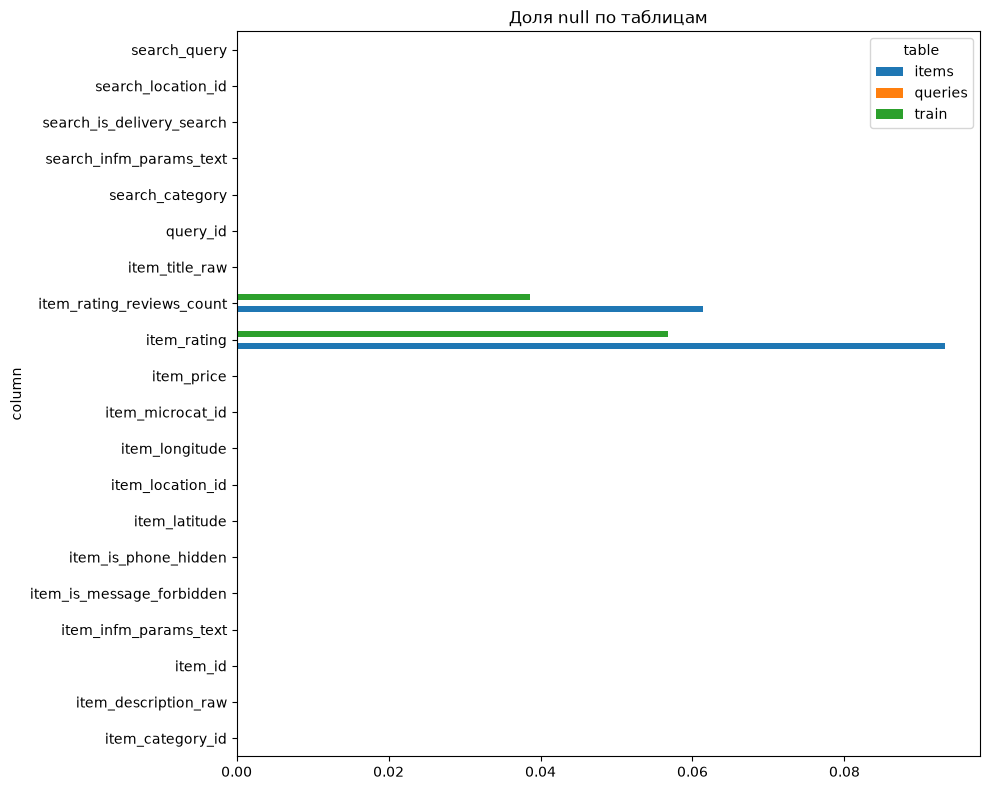

In [3]:
eda_audit = []
for eda_name, eda_df in [
    ('train', eda_train),
    ('queries', eda_queries),
    ('items', eda_items),
]:
    for eda_col in eda_df:
        eda_s = eda_df[eda_col]
        eda_audit.append(
            {
                'table': eda_name,
                'column': eda_col,
                'dtype': str(eda_s.dtype),
                'missing_share': eda_s.isna().mean(),
                'empty_share': eda_s.astype('string').eq('').mean(),
                'nunique': eda_s.nunique(),
                'rows': len(eda_df),
            }
        )
eda_audit = pd.DataFrame(eda_audit)
eda_audit.to_csv(eda_out / 'validation/schema.csv', index=False)
display(eda_audit)
eda_audit.pivot(index='column', columns='table', values='missing_share').plot.barh(
    figsize=(10, 8), title='Доля null по таблицам'
)
plt.tight_layout()
plt.savefig(eda_out / 'figures/missingness.png', dpi=150)
plt.show()


## Повторы, контексты и пересечение train → benchmark
Один текст с разными фильтрами -- разные входы модели. Для cold split все варианты одного нормализованного
текста должны уходить вместе. Повторный item_id может иметь меняющиеся признаки -- это проверяю отдельно.

In [4]:
eda_tq = prepare_queries(eda_train)
eda_bq = prepare_queries(eda_queries)
eda_counts = eda_tq.text_key.value_counts()
eda_context_counts = eda_tq.context_key.value_counts()
eda_overlap = {
    'train_rows': len(eda_train),
    'train_unique_items': eda_train.item_id.nunique(),
    'benchmark_unique_items': eda_items.item_id.nunique(),
    'full_duplicate_rows': int(eda_train.duplicated().sum()),
    'duplicate_context_item': int(
        pd.DataFrame({'key': eda_tq.context_key, 'item': eda_train.item_id})
        .duplicated()
        .sum()
    ),
    'train_texts_normalized': eda_tq.text_key.nunique(),
    'train_contexts': eda_tq.context_key.nunique(),
    'benchmark_text_seen_share': eda_bq.text_key.isin(eda_tq.text_key).mean(),
    'benchmark_context_seen_share': eda_bq.context_key.isin(eda_tq.context_key).mean(),
    'benchmark_items_seen_share': eda_items.item_id.isin(eda_train.item_id).mean(),
    'train_rows_in_benchmark_share': eda_train.item_id.isin(eda_items.item_id).mean(),
    'positive_location_mismatch_share': (
        eda_train.search_location_id != eda_train.item_location_id
    ).mean(),
    'positive_category_mismatch_share': (
        eda_train.search_category != eda_train.item_category_id
    ).mean(),
}
write_json(eda_overlap, eda_out / 'validation/overlap.json')


In [5]:
display(pd.Series(eda_overlap))
eda_item_cols = [c for c in eda_train if c.startswith('item_') and c != 'item_id']
eda_variants = eda_train.groupby('item_id')[eda_item_cols].nunique(dropna=False)
eda_variant_summary = eda_variants.gt(1).sum().sort_values(ascending=False)
display(eda_variant_summary.rename('items_with_multiple_values'))
eda_variant_summary.to_csv(eda_out / 'validation/item_conflicts.csv')
eda_train_catalog = eda_train.drop_duplicates('item_id')[
    ['item_id'] + eda_item_cols
].copy()
eda_common = eda_train_catalog.merge(
    eda_items, on='item_id', suffixes=('_train', '_bench')
)
eda_changed = {
    c: (
        eda_common[c + '_train'].astype('string').fillna('<NA>')
        != eda_common[c + '_bench'].astype('string').fillna('<NA>')
    ).mean()
    for c in eda_item_cols
}
write_json(eda_changed, eda_out / 'validation/shared_item_drift.json')
display(pd.Series(eda_changed).sort_values(ascending=False))


train_rows                          497673.000000
train_unique_items                  344825.000000
benchmark_unique_items              189212.000000
full_duplicate_rows                  30619.000000
duplicate_context_item               30654.000000
train_texts_normalized               73706.000000
train_contexts                      354241.000000
benchmark_text_seen_share                0.374796
benchmark_context_seen_share             0.044454
benchmark_items_seen_share               0.095882
train_rows_in_benchmark_share            0.066329
positive_location_mismatch_share         0.168980
positive_category_mismatch_share         0.000106
dtype: float64

item_title_raw               0
item_rating_reviews_count    0
item_rating                  0
item_price                   0
item_microcat_id             0
item_longitude               0
item_location_id             0
item_latitude                0
item_is_phone_hidden         0
item_is_message_forbidden    0
item_infm_params_text        0
item_description_raw         0
item_category_id             0
Name: items_with_multiple_values, dtype: int64

item_title_raw               0.0
item_rating_reviews_count    0.0
item_rating                  0.0
item_price                   0.0
item_microcat_id             0.0
item_longitude               0.0
item_location_id             0.0
item_latitude                0.0
item_is_phone_hidden         0.0
item_is_message_forbidden    0.0
item_infm_params_text        0.0
item_description_raw         0.0
item_category_id             0.0
dtype: float64

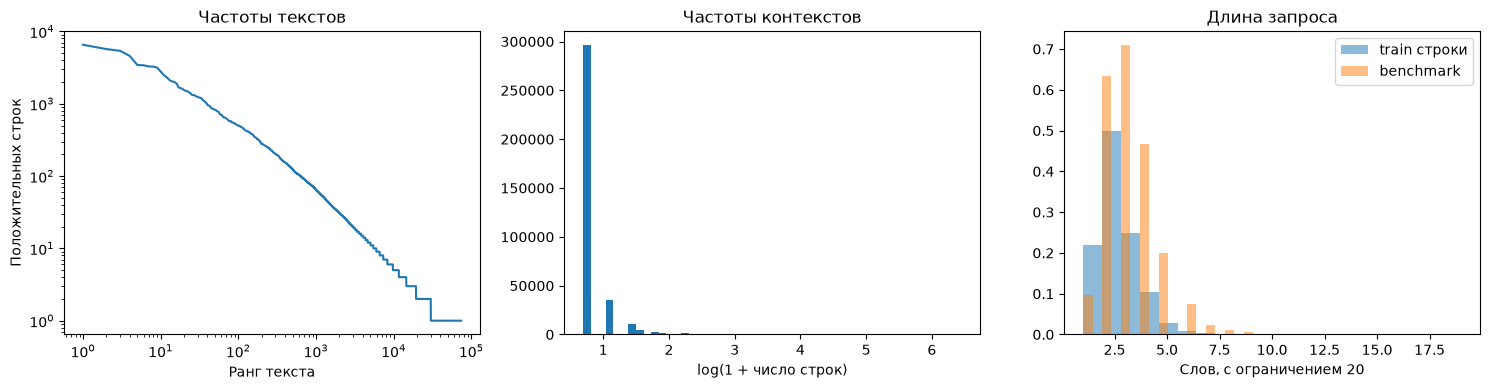

search_query
маникюр                    6540
массаж                     5702
наращивание ресниц         5395
установка кондиционеров    4573
педикюр                    3436
сантехник                  3405
вывоз мусора               3278
эвакуатор                  3263
электрик                   3158
автоэлектрик               2790
покос травы                2477
вспашка земли              2315
манипулятор                2120
грузоперевозки газель      2034
натяжные потолки           2004
наращивание ногтей         1902
торты на заказ             1682
тонировка                  1644
поклейка обоев             1611
грузчики                   1540
Name: count, dtype: int64

In [6]:
eda_fig, eda_axes = plt.subplots(1, 3, figsize=(15, 4))
eda_axes[0].loglog(np.arange(1, len(eda_counts) + 1), eda_counts.values)
eda_axes[0].set(
    title='Частоты текстов', xlabel='Ранг текста', ylabel='Положительных строк'
)
eda_axes[1].hist(np.log1p(eda_context_counts.values), bins=50)
eda_axes[1].set(title='Частоты контекстов', xlabel='log(1 + число строк)')
eda_axes[2].hist(
    eda_tq.text_key.str.split().str.len().clip(upper=20),
    bins=20,
    density=True,
    alpha=0.5,
    label='train строки',
)
eda_axes[2].hist(
    eda_bq.text_key.str.split().str.len().clip(upper=20),
    bins=20,
    density=True,
    alpha=0.5,
    label='benchmark',
)
eda_axes[2].set(title='Длина запроса', xlabel='Слов, с ограничением 20')
eda_axes[2].legend()
plt.tight_layout()
plt.savefig(eda_out / 'figures/query_distributions.png', dpi=150)
plt.show()
display(eda_train.search_query.value_counts().head(20))


## Распределения, выбросы и сдвиг каталога
Цена 0/1 может обозначать договорную цену. Не удаляю такие объявления как выбросы автоматически.
Логарифм нужен для тяжелого хвоста, исходная цена сохраняется. Рейтинг без отзывов и неизвестный рейтинг
не равны низкому качеству. Boxplot ниже использует log(1+x), без скрытого удаления хвостов из данных.

В этой раздаче отрицательная цена всегда равна `-1`: это отдельный индикатор неизвестной цены. В histogram/boxplot показываю только известные неотрицательные цены; долю служебных значений считаю отдельно. В PCA неизвестные цены заменены на missing и заполнены медианой. `showfliers=False` скрывает точки за усами только на boxplot; исходные хвосты видны в describe и гистограммах.

,count,mean,std,min,1%,50%,95%,99%,99.9%,max
item_price,344825.0,2.150652e+07,4.086050e+09,-1.000000,-1.000000,1000.000000,10000.000000,96000.000000,3.811440e+06,1.000000e+12
item_rating,321556.0,4.799642e+00,7.030948e-01,0.000000,0.000000,5.000000,5.000000,5.000000,5.000000e+00,5.000000e+00
item_rating_reviews_count,329131.0,7.419945e+01,2.786330e+02,0.000000,0.000000,21.000000,259.000000,894.000000,4.620750e+03,1.067800e+04
item_latitude,344822.0,5.379659e+01,4.864818e+00,-32.933220,43.024616,55.144853,59.974668,64.539911,6.934399e+01,7.163926e+01
item_longitude,344822.0,4.957934e+01,2.089442e+01,-118.423729,20.553384,40.961273,92.863629,131.882481,1.586435e+02,1.775189e+02


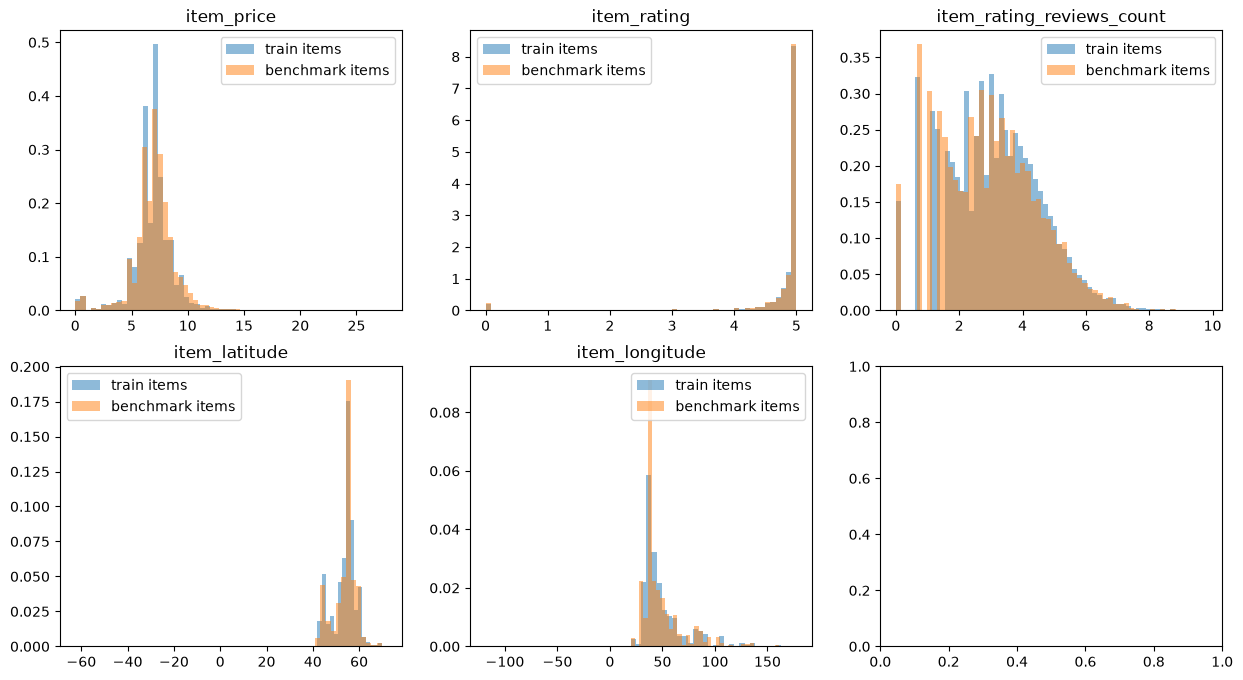

In [7]:
from scipy.stats import ks_2samp
import seaborn as sns

eda_numeric_cols = [
    'item_price',
    'item_rating',
    'item_rating_reviews_count',
    'item_latitude',
    'item_longitude',
]
eda_num_train = (
    eda_train_catalog[eda_numeric_cols]
    .apply(pd.to_numeric, errors='coerce')
    .astype(float)
)
eda_num_bench = (
    eda_items[eda_numeric_cols].apply(pd.to_numeric, errors='coerce').astype(float)
)
display(eda_num_train.describe(percentiles=[0.01, 0.5, 0.95, 0.99, 0.999]).T)
eda_drift = []
eda_fig, eda_axes = plt.subplots(2, 3, figsize=(15, 8))
for eda_j, eda_col in enumerate(eda_numeric_cols):
    eda_a, eda_b = eda_num_train[eda_col].dropna(), eda_num_bench[eda_col].dropna()
    eda_drift.append(
        {
            'column': eda_col,
            'ks_statistic': ks_2samp(eda_a, eda_b).statistic,
            'train_null': eda_num_train[eda_col].isna().mean(),
            'benchmark_null': eda_num_bench[eda_col].isna().mean(),
        }
    )
    if eda_col == 'item_price':
        eda_a, eda_b = eda_a[eda_a.ge(0)], eda_b[eda_b.ge(0)]
    if eda_col in ['item_price', 'item_rating_reviews_count']:
        eda_a, eda_b = np.log1p(eda_a.clip(lower=0)), np.log1p(eda_b.clip(lower=0))
    eda_axes.flat[eda_j].hist(
        eda_a, bins=60, density=True, alpha=0.5, label='train items'
    )
    eda_axes.flat[eda_j].hist(
        eda_b, bins=60, density=True, alpha=0.5, label='benchmark items'
    )
    eda_axes.flat[eda_j].set_title(eda_col)
    eda_axes.flat[eda_j].legend()


<Figure size 640x480 with 0 Axes>

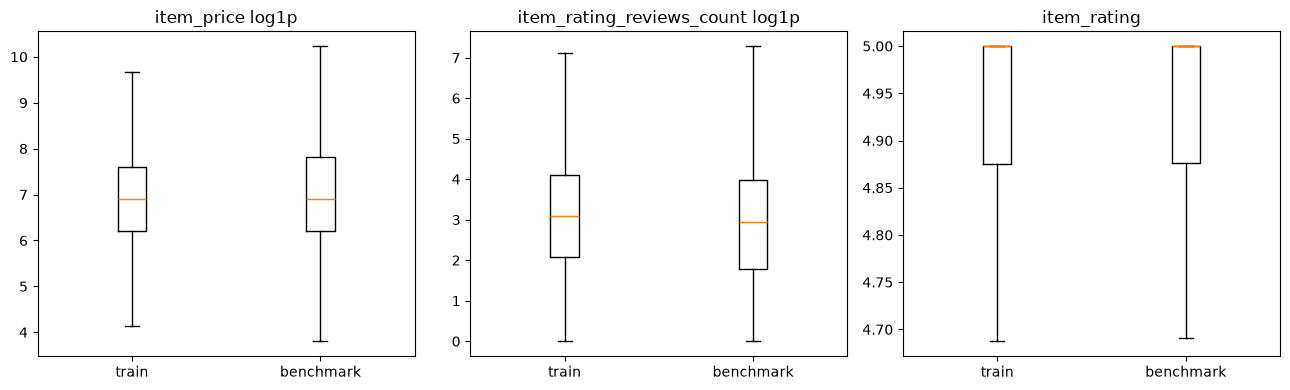

,column,ks_statistic,train_null,benchmark_null
0,item_price,0.034590,0.000000,0.000000
1,item_rating,0.018496,0.067481,0.093181
2,item_rating_reviews_count,0.041652,0.045513,0.061386
3,item_latitude,0.049129,0.000009,0.000005
4,item_longitude,0.054393,0.000009,0.000005


In [8]:
eda_axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig(eda_out / 'figures/item_distributions.png', dpi=150)
plt.show()
eda_fig, eda_axes = plt.subplots(1, 3, figsize=(13, 4))
for eda_j, eda_col in enumerate(
    ['item_price', 'item_rating_reviews_count', 'item_rating']
):
    eda_vals = [eda_num_train[eda_col].dropna(), eda_num_bench[eda_col].dropna()]
    if eda_col == 'item_price':
        eda_vals = [x[x.ge(0)] for x in eda_vals]
    if eda_col != 'item_rating':
        eda_vals = [np.log1p(x.clip(lower=0)) for x in eda_vals]
    eda_axes[eda_j].boxplot(
        eda_vals, tick_labels=['train', 'benchmark'], showfliers=False
    )
    eda_axes[eda_j].set_title(eda_col + (' log1p' if eda_col != 'item_rating' else ''))
plt.tight_layout()
plt.savefig(eda_out / 'figures/boxplots.png', dpi=150)
plt.show()
eda_drift = pd.DataFrame(eda_drift)
eda_drift.to_csv(eda_out / 'validation/numeric_drift.csv', index=False)
display(eda_drift)
eda_outliers = pd.DataFrame(
    {
        'negative_price': eda_num_train.item_price.lt(0),
        'price_zero_or_one': eda_num_train.item_price.isin([0, 1]),
        'invalid_rating': ~eda_num_train.item_rating.between(0, 5)
        & eda_num_train.item_rating.notna(),
        'invalid_lat': ~eda_num_train.item_latitude.between(-90, 90)
        & eda_num_train.item_latitude.notna(),
        'invalid_lon': ~eda_num_train.item_longitude.between(-180, 180)
        & eda_num_train.item_longitude.notna(),
    }
).mean()


In [9]:
display(eda_outliers)
eda_outliers.to_csv(eda_out / 'validation/outliers.csv')


negative_price       0.069525
price_zero_or_one    0.021121
invalid_rating       0.000000
invalid_lat          0.000000
invalid_lon          0.000000
dtype: float64

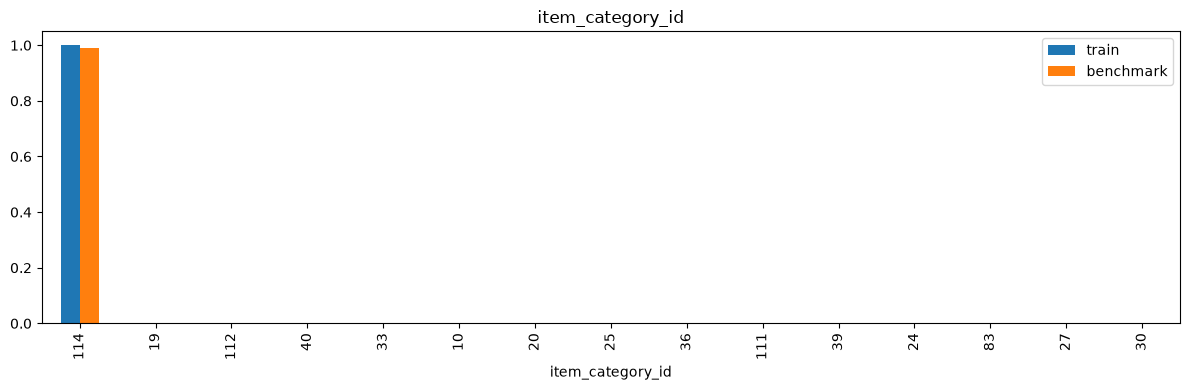

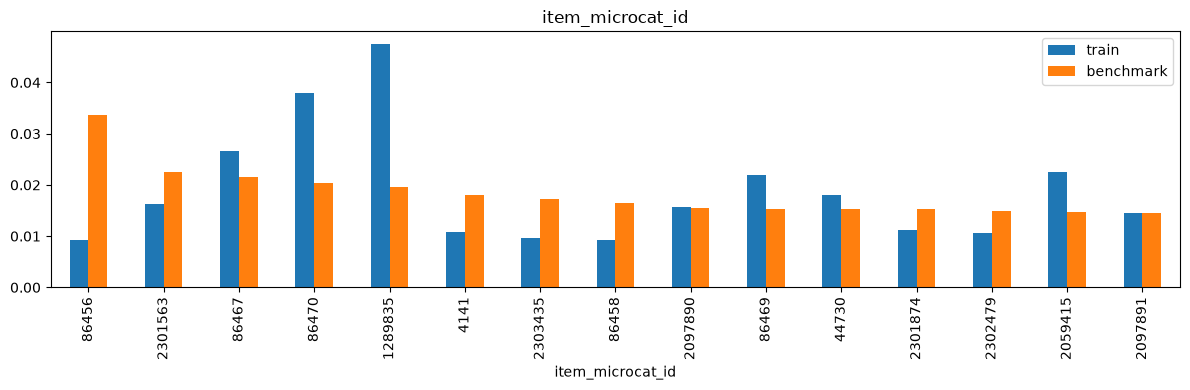

,column,total_variation,benchmark_unseen_share
0,item_category_id,0.009883,0.005650
1,item_microcat_id,0.205041,0.009291
2,item_location_id,0.106801,0.005528
3,item_is_phone_hidden,0.027563,0.000000
4,item_is_message_forbidden,0.004458,0.000000


In [10]:
eda_cat_drift = []
for eda_col in [
    'item_category_id',
    'item_microcat_id',
    'item_location_id',
    'item_is_phone_hidden',
    'item_is_message_forbidden',
]:
    eda_p = eda_train_catalog[eda_col].value_counts(normalize=True)
    eda_q = eda_items[eda_col].value_counts(normalize=True)
    eda_dist = pd.concat(
        [eda_p.rename('train'), eda_q.rename('benchmark')], axis=1
    ).fillna(0)
    eda_cat_drift.append(
        {
            'column': eda_col,
            'total_variation': abs(eda_dist.train - eda_dist.benchmark).sum() / 2,
            'benchmark_unseen_share': (
                ~eda_items[eda_col].isin(eda_train_catalog[eda_col])
            ).mean(),
        }
    )
    if eda_col in ['item_microcat_id', 'item_category_id']:
        eda_dist.nlargest(15, 'benchmark').plot.bar(figsize=(12, 4), title=eda_col)
        plt.tight_layout()
        plt.savefig(eda_out / f'figures/{eda_col}_drift.png', dpi=150)
        plt.show()
display(pd.DataFrame(eda_cat_drift))


In [11]:
pd.DataFrame(eda_cat_drift).to_csv(
    eda_out / 'validation/categorical_drift.csv', index=False
)


## Корреляции и PCA
Это диагностика числовых характеристик **объявлений**, а не доказательство предсказательной силы.
В positive-only таблице target постоянно равен 1; корреляция с ним бессмысленна.
Feature importance будет у fusion-модели на честно отложенных кандидатах в `05`.
PCA считаю после заполнения медианой и стандартизации. Category/location ID сюда не включаю.

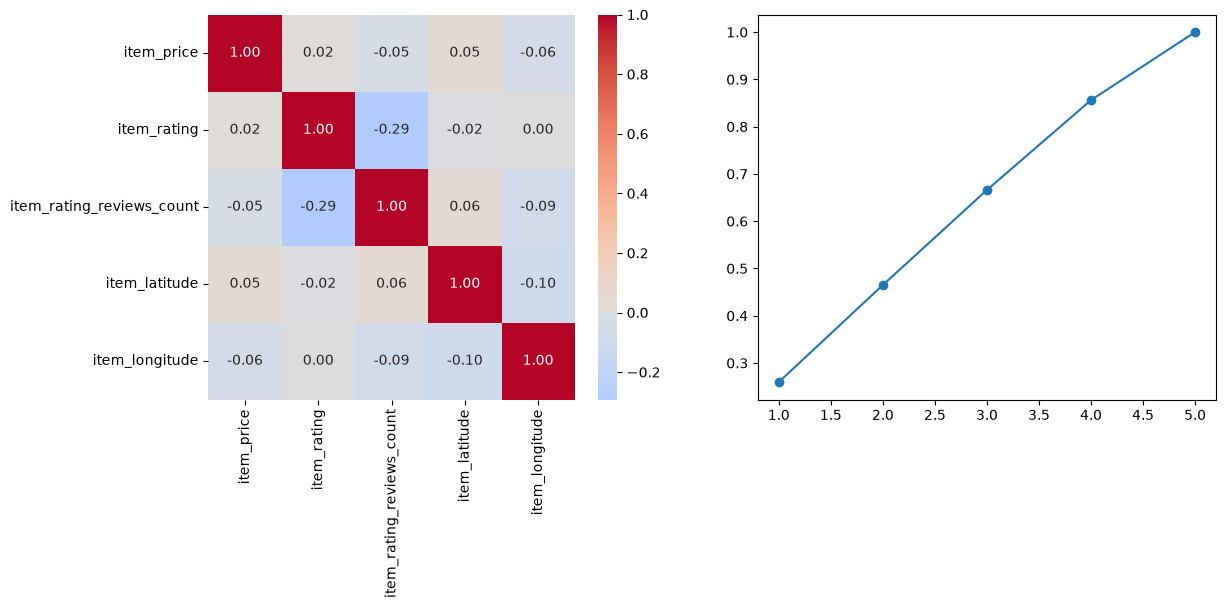

In [12]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

eda_pca_x = eda_num_train.copy()
eda_pca_x['item_price'] = np.log1p(
    eda_pca_x.item_price.where(eda_pca_x.item_price.ge(0))
)
eda_pca_x['item_rating_reviews_count'] = np.log1p(
    eda_pca_x.item_rating_reviews_count.clip(lower=0)
)
eda_fig, eda_axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(
    eda_pca_x.corr(method='spearman'),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=eda_axes[0],
)
eda_pca_matrix = StandardScaler().fit_transform(
    SimpleImputer(strategy='median').fit_transform(eda_pca_x)
)
eda_pca = PCA().fit(eda_pca_matrix)
eda_axes[1].plot(
    np.arange(1, len(eda_numeric_cols) + 1),
    np.cumsum(eda_pca.explained_variance_ratio_),
    marker='o',
)


In [13]:
eda_axes[1].set(
    xlabel='Число компонент', ylabel='Накопленная доля дисперсии', ylim=(0, 1.02)
)
plt.tight_layout()
plt.savefig(eda_out / 'figures/correlation_pca.png', dpi=150)
plt.show()
display(pd.DataFrame(eda_pca.components_, columns=eda_numeric_cols).round(3))


<Figure size 640x480 with 0 Axes>

,item_price,item_rating,item_rating_reviews_count,item_latitude,item_longitude
0,-0.022,0.660,0.694,0.178,-0.225
1,0.751,-0.062,-0.068,0.652,0.053
2,-0.388,0.119,0.040,0.396,0.823
3,-0.527,-0.317,-0.034,0.613,-0.496
4,0.089,-0.668,0.715,-0.104,0.154


## Сдвиг самих запросов

Частоты по train-строкам смещены к популярным запросам, поэтому отдельно сравниваю уникальные контексты. Ни один вариант не является известным законом отбора benchmark. Категория и location -- категориальные ID, для них использую total variation, а не числовую корреляцию.

,column,train_unit,total_variation,benchmark_unseen_share
0,search_category,positive_rows,0.090470,0.0
1,search_category,unique_contexts,0.090445,0.0
2,search_location_id,positive_rows,0.256887,0.0
3,search_location_id,unique_contexts,0.302231,0.0
4,search_is_delivery_search,positive_rows,0.000024,0.0
5,search_is_delivery_search,unique_contexts,0.000031,0.0


(array([1.533e+03, 0.000e+00, 0.000e+00, 2.360e+02, 0.000e+00, 1.440e+02,
        9.300e+01, 0.000e+00, 1.240e+02, 4.900e+01, 5.500e+01, 2.900e+01,
        2.600e+01, 2.200e+01, 3.500e+01, 1.600e+01, 1.700e+01, 7.000e+00,
        9.000e+00, 6.000e+00, 8.000e+00, 5.000e+00, 1.200e+01, 3.000e+00,
        3.000e+00, 5.000e+00, 3.000e+00, 3.000e+00, 3.000e+00, 1.000e+00,
        3.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([0.        , 0.20013949, 0.40027897, 0.60041846, 0.80055794,
        1.00069743, 1.20083691, 1.4009764 , 1.60111588, 1.80125537,
        2.00139485, 2.20153434, 2.40167383, 2.60181331, 2.8019528 ,
        3.00209228, 3.20223177, 3.40237125, 3.60251074, 3.80265022,
        4.00278971, 4.20292919, 4.40306868, 4.60320816, 4.80334765,
        5.00348714, 5.20362662, 5.40376611, 5.60390559, 5.80404508,
        6.00418456, 6.20432405, 6.40446353, 6.60460302, 6.8047425 ,
        7.00488199]),
 <BarContainer object of 35 artists>)

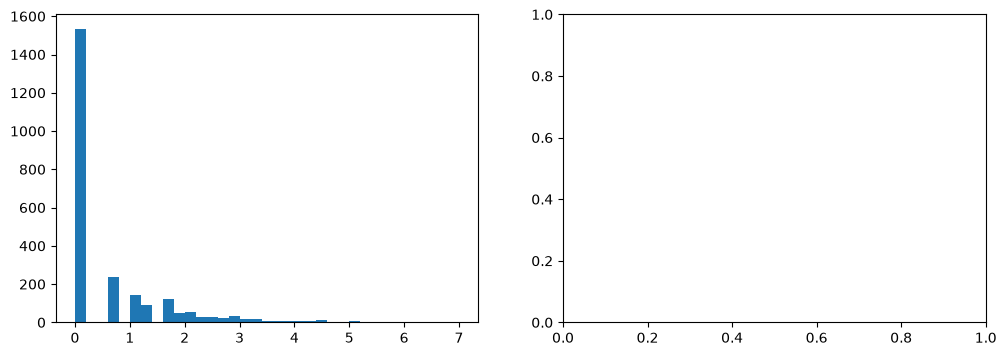

In [14]:
eda_query_drift = []
eda_unique_contexts = eda_tq.drop_duplicates('context_key')
for eda_col in ['search_category', 'search_location_id', 'search_is_delivery_search']:
    for eda_unit, eda_frame in [
        ('positive_rows', eda_tq),
        ('unique_contexts', eda_unique_contexts),
    ]:
        eda_a = eda_frame[eda_col].value_counts(normalize=True)
        eda_b = eda_bq[eda_col].value_counts(normalize=True)
        eda_dist = pd.concat(
            [eda_a.rename('train'), eda_b.rename('benchmark')], axis=1
        ).fillna(0)
        eda_query_drift.append(
            {
                'column': eda_col,
                'train_unit': eda_unit,
                'total_variation': abs(eda_dist.train - eda_dist.benchmark).sum() / 2,
                'benchmark_unseen_share': (
                    ~eda_bq[eda_col].isin(eda_frame[eda_col])
                ).mean(),
            }
        )
eda_query_drift = pd.DataFrame(eda_query_drift)
eda_query_drift.to_csv(eda_out / 'validation/query_drift.csv', index=False)
display(eda_query_drift)
eda_seen_frequency = eda_bq.text_key.map(eda_tq.text_key.value_counts()).fillna(0)
eda_fig, eda_axes = plt.subplots(1, 2, figsize=(12, 4))
eda_axes[0].hist(np.log1p(eda_seen_frequency), bins=35)


In [15]:
eda_axes[0].set(
    title='Benchmark: частота текста в train', xlabel='log(1 + положительных строк)'
)
eda_axes[1].hist(
    eda_unique_contexts.search_infm_params_text.str.len(),
    bins=40,
    density=True,
    alpha=0.5,
    label='train contexts',
)
eda_axes[1].hist(
    eda_bq.search_infm_params_text.str.len(),
    bins=40,
    density=True,
    alpha=0.5,
    label='benchmark',
)
eda_axes[1].set(title='Длина поисковых фильтров', xlabel='Символов')
eda_axes[1].legend()
plt.tight_layout()
plt.savefig(eda_out / 'figures/query_drift.png', dpi=150)
plt.show()


<Figure size 640x480 with 0 Axes>

## Выводы по данным

- Train: 497,673 положительных строк, 344,825 объявлений.
- Полных дублей: 30,619; разбиение по строкам недопустимо.
- В benchmark 37.5% знакомых нормализованных текстов,
  9.6% знакомых объявлений. Нужны cold-query и cold-item срезы.
- Равенство location отсекло бы 16.9% позитивов,
  равенство category -- 0.0%. Это мягкие признаки.
- Локальный каталог -- объединение всех доступных item metadata; benchmark metadata имеет приоритет
  при конфликте. Для финальной сдачи кандидаты ограничиваются benchmark корпусом.
- У 6.95% уникальных train items цена равна -1; выделяем служебную цену отдельно от бесплатной.
  Максимальная цена почти 10¹²: сохраняю объявление, использую логарифм и относительную цену.
- Мы оцениваю восстановление выбранных объявлений, а не полную семантическую релевантность.
  Неразмеченные кандидаты -- потенциальные false negatives.
